In [1]:
# Importing needed code

from pathlib import Path
from typing import Callable, Literal
from datetime import datetime, time, date, timedelta
from dataclasses import dataclass
from multiprocessing.pool import Pool

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.arc_paths import get_report_root, INPUT_DATA_FOLDER
from data_processing.dataframe_validation import DataframeColumn, get_df_col
from data_processing.loading.dataframe_loading import load_psd, load_signals
from data_processing.loading.timetag_processing import calculate_timetag_hours, calculate_event_time
from data_processing.processing.bimodal_fitting import (
    split_params, 
    get_bimodal_fit, 
    scan_histogram_slices,
    get_psd_energy_histogram
)
from data_processing.processing.dataframe_manipulation import generate_full_neutron_df, generate_neutron_signals
from data_processing.processing.figure_of_merit import ( 
    FOM, 
    gaussian, 
    bimodal
)
from data_processing.processing.neutron_classification import generate_nasa_neutron_window, classify
from data_processing.reporting.signal_investigator import SignalInvestigator
from data_processing.reporting.plotting import plot_classification, plot_psd_histogram

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

Matplotlib created a temporary config/cache directory at /tmp/pbs.4853429.pbsha.ib.sockeye/matplotlib-_xqos_hs because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


# Inputs

In [29]:
# Data location

experiment_name = '2023-04-05_PIII_Cu-disk-5 kV-10 min run 5times'
experiment_display_name = 'PIII with Cu disk at 5kV - April 5 2023'

In [30]:
# Start Time

# TODO get this from exp_info.toml
start_datetime = datetime.fromisoformat('2023-04-05T16:29:26-07:00')

# Load Data

In [4]:
N_ROOT = INPUT_DATA_FOLDER / experiment_name / 'processed_data/neutrons'
REPORT_ROOT = get_report_root(experiment_name)

In [5]:
if N_ROOT.is_dir() and len(list(N_ROOT.iterdir())) > 0:
    pass  # TODO try to load neutrons data
else:
    # Fit settings
    resolution = 512
    start_scan_idx = 0
    end_scan_idx = 420
    
    # Load PSD data
    psd_report = load_psd(experiment_name)
    
    # Add time columns (hours, event_time)
    psd_report = calculate_timetag_hours(psd_report)
#     caen_start_datetime = datetime.combine(date.today(), caen_start_time)
    psd_report = calculate_event_time(psd_report, start_datetime)
        
    # Load signals data
    signals_df = load_signals(experiment_name)
    
    Z, xe, ye = get_psd_energy_histogram(psd_report, resolution=resolution)
    
    end_scan_idx = min(end_scan_idx, len(Z))
    all_slice_xs = xe[:end_scan_idx]
    psd_bin_lbs = ye[:-1]  # TODO do I need this?

    # Default
    default_bounds = (
        (0.1, 0.01, 1, 
         0.25, 0.01, 0),
        (0.2, 0.1, Z.max(),
         0.38, 0.04, 2000)
    )

    bounds_a = (
        (0.1, 0.01, 1, 
         0.35, 0.01, 0),
        (0.2, 0.1, Z.max(),
         0.36, 0.04, 2000)
    )

    bounds_b = (
        (0.1, 0.01, 1, 
         0.34, 0.01, 0),
        (0.2, 0.1, Z.max(),
         0.36, 0.03, 2000)
    )  # TODO do I need this?


    # Ranged Example
    bounds = [
        ((0,60), bounds_a),
    ]
    
    slice_fit_df, _ = scan_histogram_slices(
        psd_bin_lbs,
        Z.T,
        bounds=bounds,
        default_bounds=default_bounds,
        start_idx=start_scan_idx,
        end_idx=end_scan_idx
    )
    
    # Generate neutron window and classify
    n_window_lb, n_window_ub = generate_nasa_neutron_window(
        slice_fit_df,
        all_slice_xs
    )
    psd_report = classify(
        psd_report,
        n_window_lb,
        n_window_ub,
        DataframeColumn.NEUTRON_CLASS
    )
    
    # Join PSD and signals
    psd_report = generate_full_neutron_df(
        psd_report, 
        signals_df, 
        DataframeColumn.NEUTRON_CLASS
    )

In [6]:
psd_report.head()

,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total,TIMETAG_HOURS,EVENT_TIME,EVENT_TIME_PS,NASA,0,...,190,191,192,193,194,195,196,197,198,199
605,0.342700,312,486,5082182927039,0.358025,0.001412,2023-04-05 16:29:31.082182927-07:00,39,True,14744,...,14744,14744,14747,14747,14748,14748,14723,14723,14751,14751
1712,0.235770,227,333,14251598444323,0.318318,0.003959,2023-04-05 16:29:40.251598444-07:00,323,True,14747,...,14751,14751,14742,14742,14750,14750,14744,14744,14725,14725
2539,0.971246,976,1384,21048520634810,0.294798,0.005847,2023-04-05 16:29:47.048520634-07:00,810,True,14744,...,14730,14730,14742,14742,14736,14736,14712,14712,14706,14706
3919,0.419607,399,596,32385792638405,0.330537,0.008996,2023-04-05 16:29:58.385792638-07:00,405,True,14750,...,14744,14744,14741,14741,14740,14740,14733,14733,14745,14745
3960,0.346195,292,491,32763512493239,0.405295,0.009101,2023-04-05 16:29:58.763512493-07:00,239,True,14748,...,14744,14744,14740,14740,14744,14744,14750,14750,14752,14752


In [7]:
investigator = SignalInvestigator(psd_report)

In [8]:
investigator.count_results()

2946

<IPython.core.display.Javascript object>


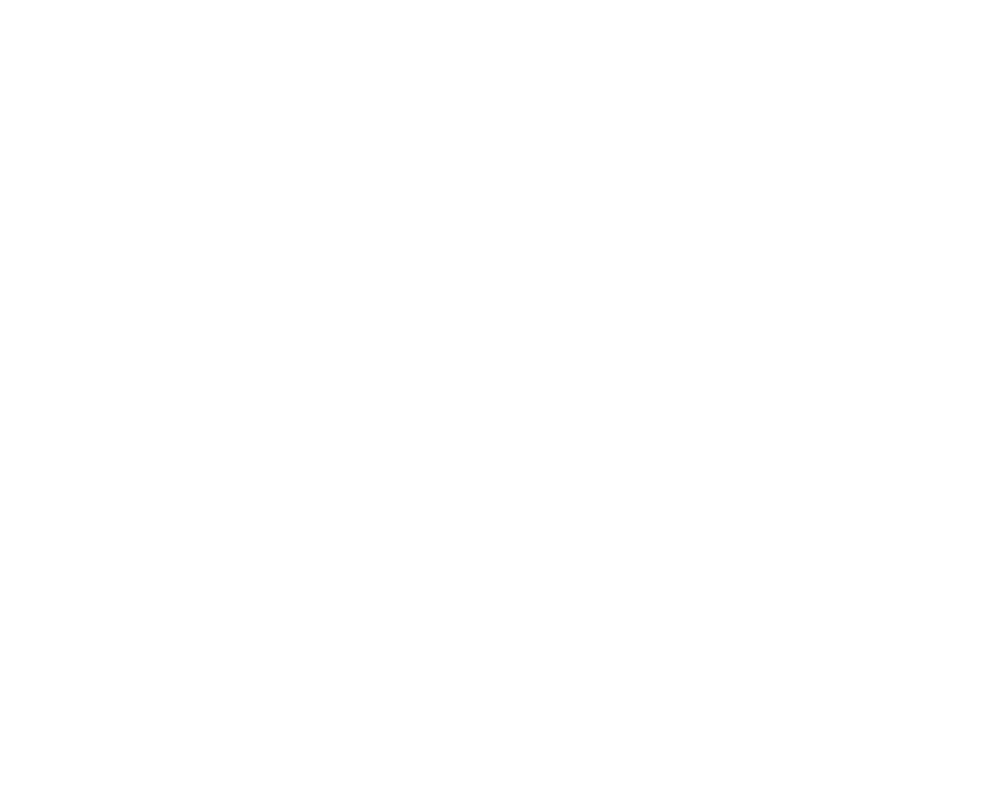

(<Figure size 1000x800 with 1 Axes>,
 <AxesSubplot: xlabel='Energy (MeVee)', ylabel='PSD'>)

In [9]:
%matplotlib notebook
# Entire PSD histogram

investigator.visualize_scatter()

In [10]:
time_range = ["17:40:05", "17:59:55"]
datetime_range = tuple([f'2023-04-05T{time_bound}-07:00' for time_bound in time_range])

investigator.update_query(time=datetime_range)

<IPython.core.display.Javascript object>


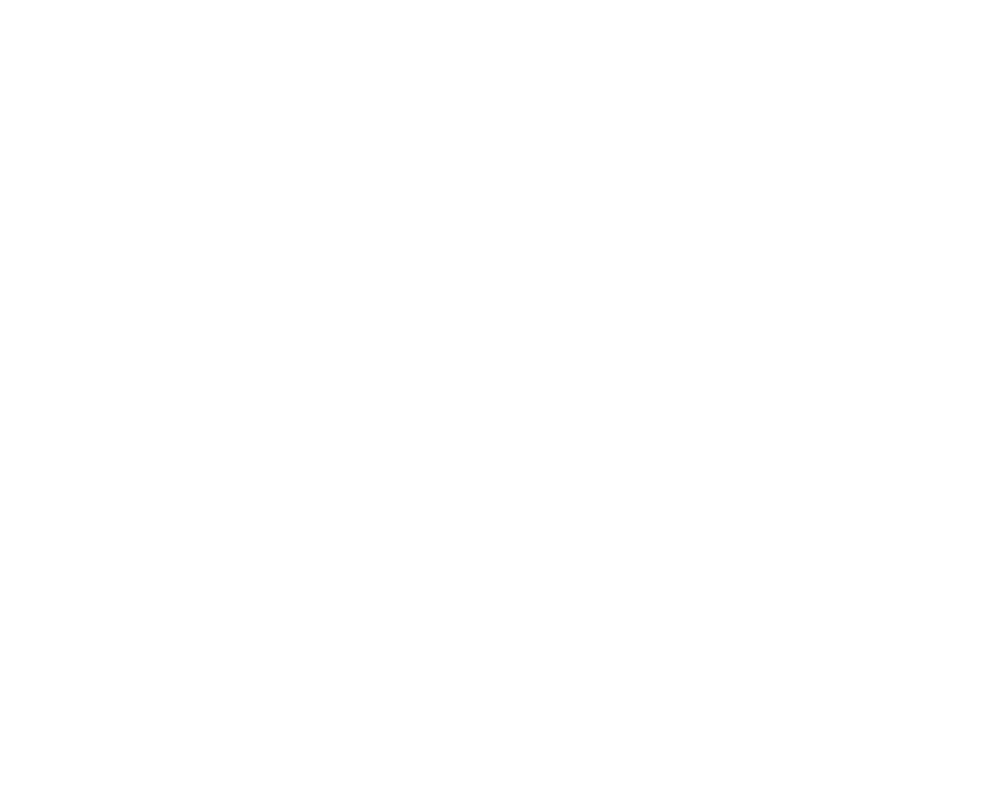

(<Figure size 1000x800 with 1 Axes>,
 <AxesSubplot: xlabel='Tail', ylabel='Total'>)

In [11]:
from data_processing.reporting.plotting import plot_bounded_scatter
from data_processing.reporting.plot_configs import *
from data_processing.dataframe_validation import get_df_col, DataframeColumn

df = investigator.perform_query()
dataset_size = investigator.count_results()
energy_col = get_df_col(df, DataframeColumn.ENERGY)
short_col = get_df_col(df, DataframeColumn.ENERGYSHORT)
plot_bounded_scatter(energy_col-short_col, 
                     energy_col,  
                     "Tail", 
                     "Total",
                     s=SCATTER_MARKER_SIZE_LARGE)

In [12]:
investigator.count_results()

603

<IPython.core.display.Javascript object>


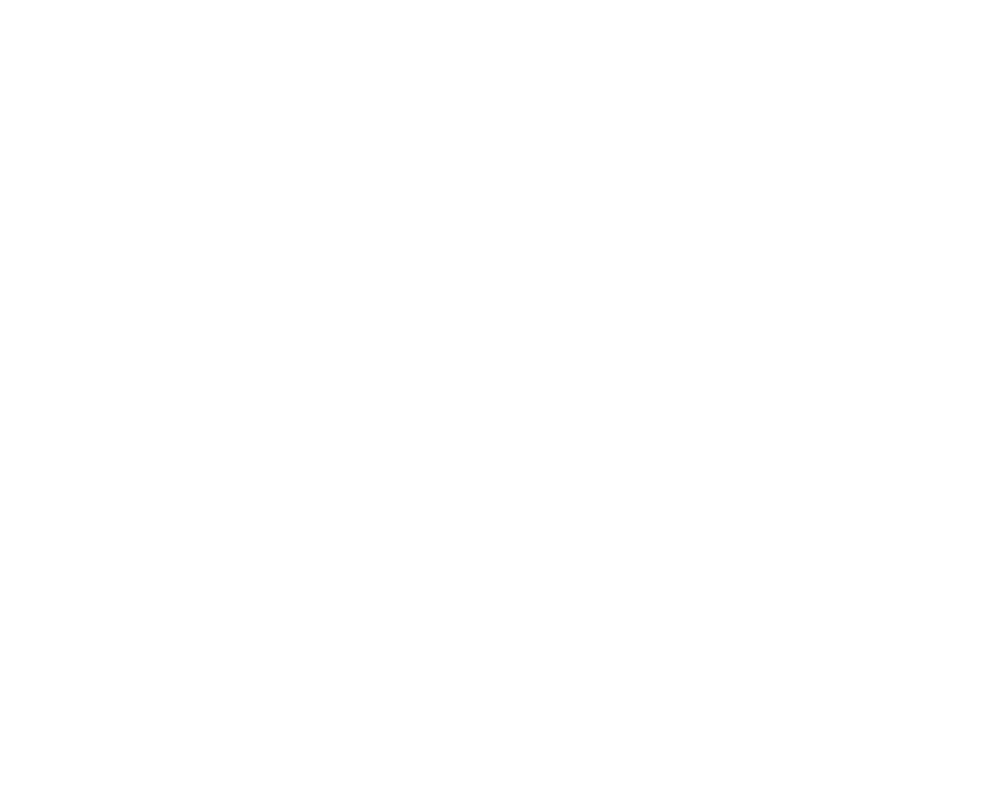

(<Figure size 1000x800 with 1 Axes>,
 <AxesSubplot: xlabel='Energy (MeVee)', ylabel='PSD'>)

In [13]:
investigator.visualize_scatter()

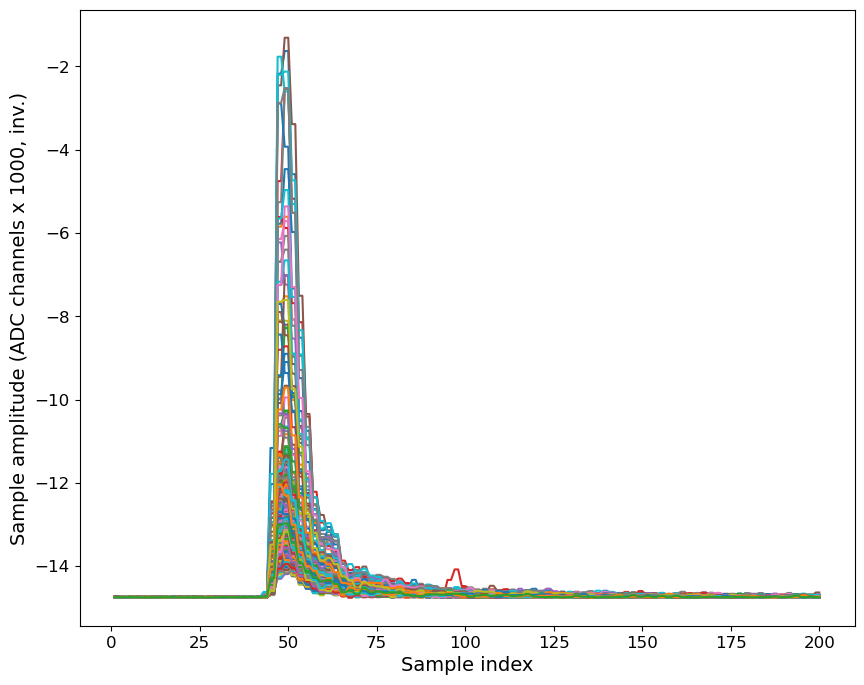

In [14]:
%matplotlib inline

fig, ax = investigator.visualize_signals()
# fig.suptitle("Neutron Signals", fontsize=24)
# ax.set_title("PIII Off Repeat 4 (17:40-18:00)", fontsize=22)
# ax.tick_params(axis='both', which='major', labelsize=14)
# xticks = list(range(0,201,25))
# ax.set_xticks(xticks)
# ax.ticklabel_format(style='sci',scilimits=(0,3), axis='y')
# ax.set_xlim(-10, 210)
# ax.set_xlabel('Sample index', fontsize=18)
# ax.set_ylabel('Signal amplitude (ADC channels, inverted)', fontsize=18)

In [15]:
on_time_ranges = [
    ['16:30:05', '16:39:55'],
    ['16:50:05', '16:59:55'],
    ['17:10:05', '17:19:55'],
    ['17:30:05', '17:39:55'],
    ['17:50:05', '17:59:55']
]
off_time_ranges = [
    ['16:40:05', '16:49:55'],
    ['17:00:05', '17:09:55'],
    ['17:20:05', '17:29:55'],
    ['17:40:05', '17:49:55'],
    ['18:00:05', '18:09:55']
]
# datetime_range = tuple([f'2023-04-05T{time_bound}-07:00' for time_bound in time_range])
on_dt_ranges = [tuple([f'2023-04-05T{time_bound}-07:00' for time_bound in time_range]) for time_range in on_time_ranges]
off_dt_ranges = [tuple([f'2023-04-05T{time_bound}-07:00' for time_bound in time_range]) for time_range in off_time_ranges]

In [16]:
on_frames = []

for dt_range in on_dt_ranges:
    investigator.update_query(time=dt_range)
    df = investigator.perform_query()
    on_frames.append(df)

on_df = pd.concat(on_frames)
on_df.shape

(2517, 209)

In [17]:
off_frames = []

for dt_range in off_dt_ranges:
    investigator.update_query(time=dt_range)
    df = investigator.perform_query()
    off_frames.append(df)

off_df = pd.concat(off_frames)
off_df.shape

(368, 209)

In [18]:
bin_count = 'fd'

on_en_counts, en_bins = np.histogram(on_df['CALIB_ENERGY'],bin_count)
off_en_counts, _ = np.histogram(off_df['CALIB_ENERGY'],en_bins)

In [19]:
print((en_bins[1]-en_bins[0])*1000)

31.80254320987655


In [20]:
print(len(en_bins)-1)

81


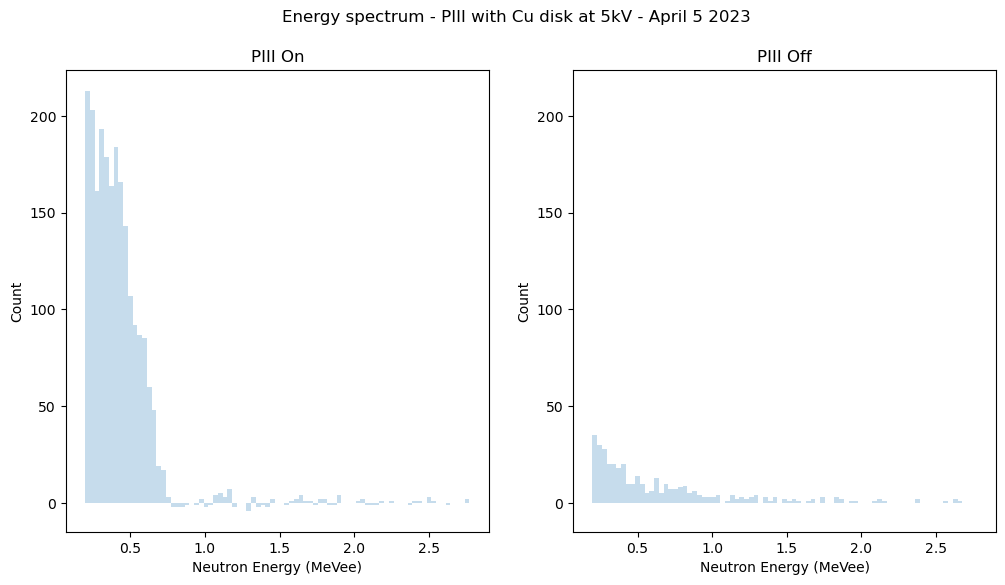

In [21]:
stairs_format = dict(lw=2, alpha=0.25, fill=True)

fig, axs = plt.subplots(1, 2, squeeze=False, figsize=(12, 6))
fig.suptitle(f'Energy spectrum - {experiment_display_name}')

ax_on, ax_off = axs[0]

ax_on.stairs(on_en_counts-off_en_counts, en_bins, **stairs_format)
ax_on.set_title("PIII On")
y_limits = ax_on.get_ylim()

ax_off.stairs(off_en_counts, en_bins, **stairs_format)
ax_off.set_title("PIII Off")
ax_off.set_ylim(y_limits)

for ax in axs[0]:
    ax.set_ylabel("Count")
    ax.set_xlabel("Neutron Energy (MeVee)")

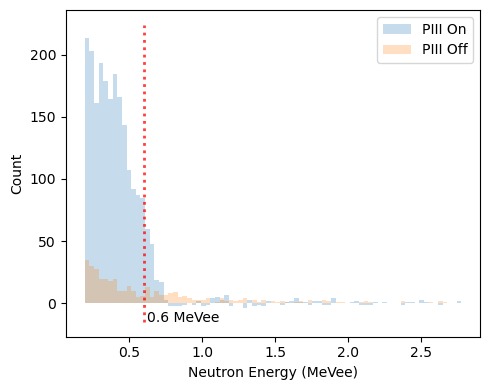

In [28]:
stairs_format = dict(lw=2, alpha=0.25, fill=True)
lines_format = dict(colors='red', linestyles='dotted', 
                    linewidth=2, alpha=0.75)

fig, ax = plt.subplots(figsize=(5, 4))
# fig.suptitle(f'Energy spectrum - {experiment_display_name}')

ax.stairs(on_en_counts-off_en_counts, en_bins, 
          label="PIII On", **stairs_format)
ax.stairs(off_en_counts, en_bins, label="PIII Off", **stairs_format)
ax.vlines(0.6, *ax.get_ylim(), **lines_format)
ax.annotate('0.6 MeVee', (0.6, -15), xytext=(0.625, -15), fontsize=10)

ax.set_ylabel("Count", fontsize=10)
ax.set_xlabel("Neutron Energy (MeVee)", fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend()
fig.tight_layout()
# ax.set_xlim(0.15, 2.5)